In [1]:
import numpy as np
import os
import pandas as pd
from typing import Optional, Sequence, Iterable, Any
# import roicat
import re
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from matplotlib.cm import get_cmap
import random

In [18]:
def filter_neurons_by_session_count(
    df: pd.DataFrame,
    count: int,
    session_cols: Optional[Sequence] = None,
    absent_values: Optional[Iterable[Any]] = None,
    exact: bool = True  # New parameter to specify exact or at least
) -> pd.DataFrame:
    """
    Filter neurons (rows) by the exact or at least number of sessions in which they appear.

    Assumptions:
    - The first column is the neuron_ID.
    - Remaining columns are session columns (0..n).
    - A neuron is absent in a session if the cell is NaN, -1 (int), or "-1" (str).

    Params:
    - count: exact number of sessions the neuron must appear in (or at least if exact is False).
    - session_cols: optional list of session column names; defaults to all except the first column.
    - absent_values: optional iterable of values that indicate absence; defaults to [-1, "-1"].
    - exact: if True, filter for exact count; if False, filter for at least count.

    Returns:
    - A filtered copy of df containing only rows with exactly or at least `count` present sessions.
    """
    if session_cols is None:
        session_cols = df.columns[1:]  # exclude neuron_ID column

    if absent_values is None:
        absent_values = (-1, "-1")

    sess = df[session_cols]

    # Build mask of "absent" entries: NaN OR equals any of the absent_values
    absent_mask = sess.isna()
    for v in absent_values:
        absent_mask = absent_mask | sess.eq(v)

    # Present if not absent
    present_counts = (~absent_mask).sum(axis=1)

    if exact:
        sel = present_counts.eq(count)
    else:
        sel = present_counts.ge(count)  # Use greater than or equal for at least

    return df.loc[sel].copy()
    

def apply_ID_shift(df, col, shift_value, skip_value=-1):
    """
    Adds `shift_value` to all numeric string values in a column,
    skipping `skip_value` (can be int or str) and any strings containing letters.

    Args:
        df (pd.DataFrame): The DataFrame to update.
        col (str): Column name.
        shift_value (int): Amount to add to numeric values.
        skip_value (int or str): Value to skip (default -1).
    """
    def transform(x):
        # Handle missing values (NaN, None etc.)
        if pd.isna(x):
            return x
        # Compare x to skip_value as both int and str
        if x == skip_value or str(x) == str(skip_value):
            return x
        x_str = str(x)
        if re.fullmatch(r"-?\d+", x_str):
            return str(int(x_str) + shift_value)
        return x
    new_col = df[col].apply(transform)
    return new_col


In [4]:
# Use suite2p environment if directly loading suite2p outputs
file_dir = "Z:\\2p\experiment1\\MZ_CA1_WD_M7\\d7\\suite2p\\plane0"
F = np.load(os.path.join(file_dir,'F.npy'), allow_pickle=True)
stat = np.load(os.path.join(file_dir, 'stat.npy'), allow_pickle=True)
# old_stat = np.load(os.path.join(file_dir, 'stat_orig.npy'), allow_pickle=True)
iscell = np.load(os.path.join(file_dir, 'iscell.npy'))

In [8]:
file_dir = "Z:\\2p\experiment1\\MZ_CA1_WD_M7\\"
ROI_table_full = pd.read_csv(os.path.join(file_dir, "ROI_table_full_plane0.csv"))
ROI_table_copy = ROI_table_full.copy()

In [24]:
ROI_table_full['6'] = apply_ID_shift(ROI_table_copy, '6', 1, skip_value=-1)

In [29]:
pd.set_option('display.max_rows', None)
ROI_table_full.iloc[1500:1599]

,Neuron_ID,0,1,2,3,4,5,6,7,8,9
1500,1500,-1,-1,-1,506,-1,-1,-1,-1,-1,379
1501,1501,-1,345,249,325,470,-1,-1,433,294,-1
1502,1502,-1,334,329,-1,351,-1,-1,-1,-1,-1
1503,1503,-1,793,-1,-1,-1,-1,-1,-1,-1,369
1504,1504,-1,1104,1109,-1,-1,1192,-1,-1,-1,-1
1505,1505,311,448,382,294,297,324,477,381,837,-1
1506,1506,-1,849,717,606,543,-1,708,-1,864,-1
1507,1507,264,391,367,156,359,489,299,-1,544,-1
1508,1508,995,1302,1088,1013,-1,-1,-1,-1,874,1009
1509,1509,89,-1,-1,-1,-1,-1,-1,-1,-1,91


In [30]:
ROI_table_full.to_csv(os.path.join(file_dir, "ROI_table_full_plane0_current.csv"))

In [10]:
# Main folder for the animal
mousename = 'MZ_CA1_WD_M5'
sourcedir = r'Z:\2p\experiment1'

dir_allOuterFolders = os.path.join(sourcedir,mousename)

pathSuffixToStat = 'stat.npy' # cell's spatial info, shape etc
pathSuffixToOps = 'ops.npy' # program loading/running setting file 
pathSuffixToIscell = 'iscell.npy' # is cell flags for future use

paths_all_stat = roicat.helpers.find_paths(
    dir_outer=dir_allOuterFolders,
    reMatch=pathSuffixToStat,
    depth=10,
)[:]
paths_all_ops  = [str(Path(path).resolve().parent / pathSuffixToOps) for path in paths_all_stat]
paths_all_iscell  = [str(Path(path).resolve().parent / pathSuffixToIscell) for path in paths_all_stat]


In [13]:
# Load paths to stat and ops files into ROICAT
# planes = ['plane2', 'plane0', 'plane0', 'plane0', 'plane0', 'plane0', 'plane0', 'plane0', 'plane0']  # Adjusted for your example
planes = ['plane1'] * 9  # 'plane1' repeated 9 times
days = [1, 3, 4, 5, 6, 7, 8, 9, 10]

# Initialize lists to accumulate paths
paths_stat = []
paths_ops = []
paths_iscell = []

for plane, day in zip(planes, days):
    # Filter paths for the current plane and day
    stat_path = [x for x in paths_all_stat if plane in x and f'd{day}\\' in x]
    ops_path = [x for x in paths_all_ops if plane in x and f'd{day}\\' in x]
    iscell_path = [x for x in paths_all_iscell if plane in x and f'd{day}\\' in x]

    # Append the filtered paths to the respective lists
    paths_stat.extend(stat_path)
    paths_ops.extend(ops_path)
    paths_iscell.extend(iscell_path)

In [14]:
data = roicat.data_importing.Data_suite2p(
    paths_statFiles=paths_stat[:],
    paths_opsFiles=paths_ops[:],
    um_per_pixel=3.0,  ## IMPORTANT PARAMETER. Use a list of floats if values differ in each session.
    new_or_old_suite2p='new',
    type_meanImg='meanImgE', # raw mean image across all registered frames
)

c:\Users\mzhou9\Anaconda3\envs\roicat\Lib\site-packages\roicat\util.py:416: UserWarning: RH WARNING: unable to get gcc version. Got error: [WinError 2] The system cannot find the file specified
  warnings.warn(f'RH WARNING: unable to get gcc version. Got error: {e}')


Starting: Importing FOV images from ops files
Completed: Set FOV_height and FOV_width successfully.
Completed: Imported 9 FOV images.
Setting FOV_images...
Completed: Set FOV_images for 9 sessions successfully.
Importing spatial footprints from stat files.


  0%|          | 0/9 [00:00<?, ?it/s]

Imported 9 sessions of spatial footprints into sparse arrays.
Completed: Set spatialFootprints for 9 sessions successfully.
Completed: Created session_bool.
Completed: Created centroids.
Starting: Creating centered ROI images from spatial footprints...
Completed: Created ROI images.


In [28]:
ROI_table_full = pd.read_csv(os.path.join(dir_allOuterFolders, f"ROI_table_full_{plane}.csv"))
ROI_table = filter_neurons_by_session_count(ROI_table_full, count=7, exact=False)
pd.set_option('display.max_rows', None)
print(len(ROI_table))

266


C:\Users\mzhou9\AppData\Local\Temp\1\ipykernel_30624\2888685545.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap(cmap_name, n)


[0, 1, 2, 3, 4, 5, 6, 7, 8]


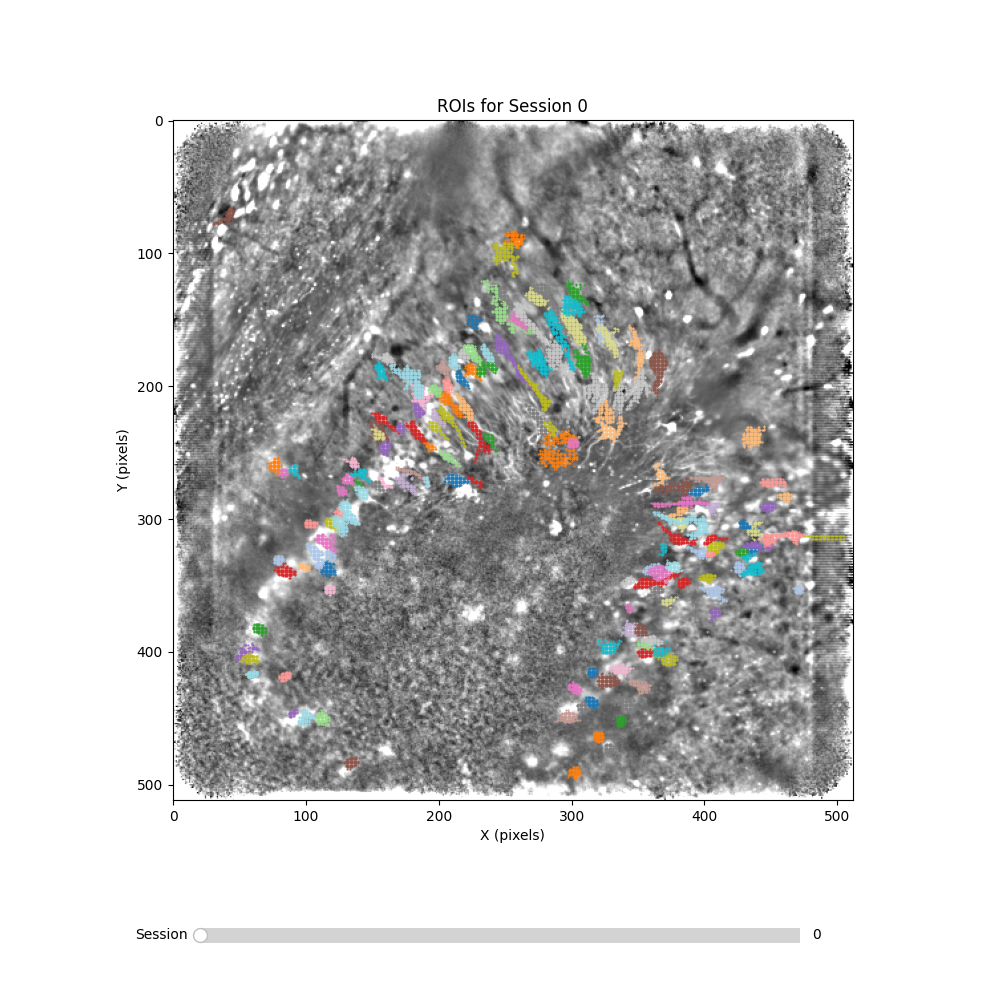

In [46]:
%matplotlib widget

def generate_roi_colors_by_row(ROI_table, cmap_name="tab20"):
    n = len(ROI_table)
    if n == 0:
        return []
    # Discrete colormap with n entries; each cmap(i) returns an RGBA tuple
    cmap = get_cmap(cmap_name, n)
    return [list(map(float, cmap(i))) for i in range(n)]

roi_colors = generate_roi_colors_by_row(ROI_table)

# Function to update the plot based on the slider value
def plot_ROIs_across_sessions(session_idx, ROI_table):
    ax.clear()  # Clear the current plot

    # Get the FOV image for the selected session
    fov_image = data.FOV_images[session_idx]

    # Get the spatial footprints for the selected session
    session_footprints = data.spatialFootprints[session_idx]

    # Get the ROI indices to include from the ROI_table
    column_name = str(session_idx)  # Convert session_idx to string
    roi_indices = ROI_table.loc[:, column_name].values  # Use .loc with the column name as a string

    # Reshape the flattened spatial footprint to match the FOV image dimensions
    fov_shape = fov_image.shape  # (height, width)

    # Plot the FOV image
    ax.imshow(fov_image, cmap='gray')  # Display the FOV image

    # Overlay each ROI
    for ir, roi_idx in enumerate(roi_indices):  # Iterate over rows (ROIs)
        # Extract the ROI's spatial footprint as a sparse row
        roi_footprint = session_footprints[roi_idx, :].toarray().reshape(fov_shape)
        roi_color = roi_colors[ir]  # Get the color from the generated color map
        
        # Get the coordinates of non-zero pixels in the ROI
        ypix, xpix = np.nonzero(roi_footprint)

        # Plot the ROI
        ax.plot(xpix, ypix, '.', markersize=1, color=roi_color)

    # Customize the plot
    ax.set_title(f"ROIs for Session {session_idx}")
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")

    fig.canvas.draw_idle()  # Redraw the canvas


# Generate consistent colors for all ROIs
roi_colors = generate_roi_colors_by_row(ROI_table)

sessions_to_include = list(range(data.n_sessions))

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 10))
plt.subplots_adjust(bottom=0.2)  # Adjust space for the slider

# Add a slider below the plot
ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03])  # Position of the slider
slider = Slider(ax_slider, 'Session', 0, len(sessions_to_include) - 1, valinit=0, valstep=1)

# Function to update the plot when the slider value changes
def update_plot(val):
    session_idx = sessions_to_include[int(slider.val)]  # Map slider value to session index
    plot_ROIs_across_sessions(session_idx, ROI_table)  # Update the plot

# Connect the slider to the update function
slider.on_changed(update_plot)

# Initialize the plot with the first session
plot_ROIs_across_sessions(0, ROI_table)

plt.show()